In [1]:
# !mkdir /root/.config/kaggle
# !cp kaggle.json /root/.config/kaggle/
# !kaggle datasets download anthonytherrien/dog-vs-cat
# !unzip /content/dog-vs-cat.zip

In [2]:
from tensorflow import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers , Model


In [3]:
import os
from PIL import Image

data_dir = "/content/animals"
num_removed = 0

print("Starting robust scan...")

for folder_name in ("cat", "dog"):
    folder_path = os.path.join(data_dir, folder_name)
    print(f"Scanning folder: {folder_path}")

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)

        try:
            with Image.open(fpath) as img:
                img.load()
        except Exception as e:
            print(f"Corrupted file found, removing: {fpath} ({e})")
            os.remove(fpath)
            num_removed += 1

print(f"\nRobust scan complete. Removed {num_removed} additional corrupted files.")

Starting robust scan...
Scanning folder: /content/animals/cat
Scanning folder: /content/animals/dog

Robust scan complete. Removed 0 additional corrupted files.


In [4]:
data_dir = '/content/animals'
BATCH_SIZE = 32
IMG_SIZE = (160, 160)

In [5]:
train_dataset = tf.keras.utils.image_dataset_from_directory(data_dir,
                                                            shuffle=True,
                                                            seed=123,
                                                            validation_split=0.2,
                                                            subset='training',
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE)

Found 1000 files belonging to 2 classes.
Using 800 files for training.


In [6]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(data_dir,
                                                            shuffle=True,
                                                            seed=123,
                                                                 validation_split=0.2,
                                                            subset='validation',
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE)

Found 1000 files belonging to 2 classes.
Using 200 files for validation.


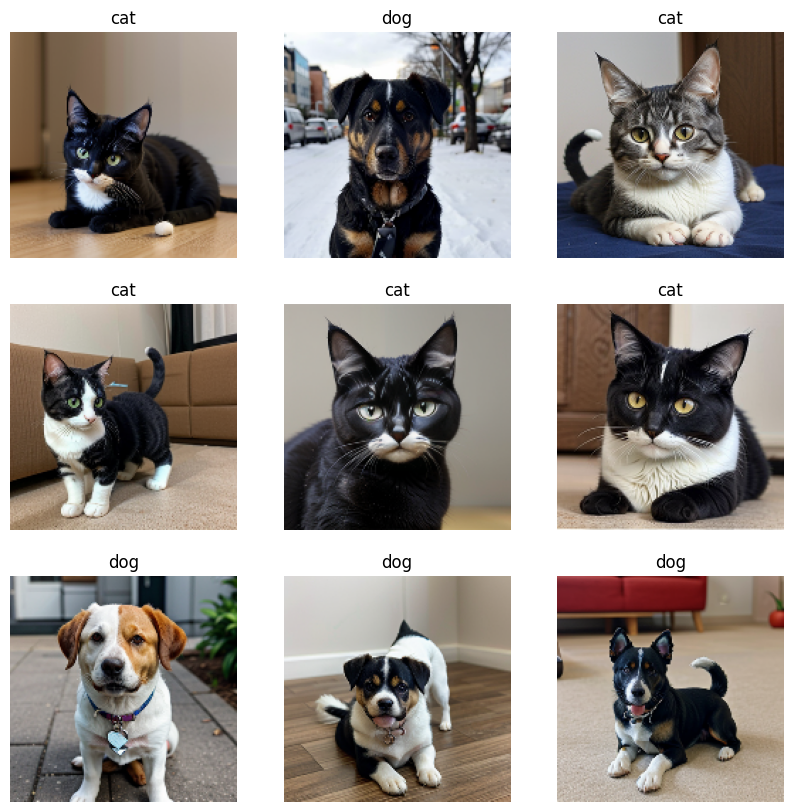

In [7]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [8]:
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 5)
validation_dataset = validation_dataset.skip(val_batches // 5)

In [9]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))

Number of validation batches: 6
Number of test batches: 1


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [11]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

In [12]:
base_model = tf.keras.applications.MobileNetV2(
                                              include_top=False,
                                               weights='imagenet')

/tmp/ipython-input-2606749161.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


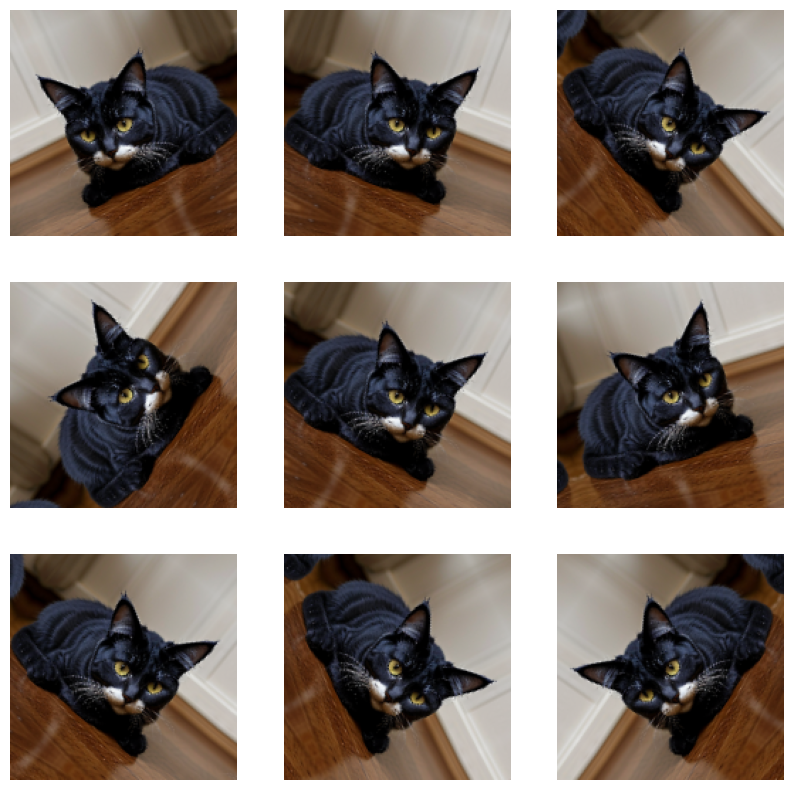

In [13]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

In [14]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [15]:
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)

In [16]:
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

In [17]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 1280)


In [18]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

In [19]:
prediction_layer = tf.keras.layers.Dense(1)

In [20]:
inputs = tf.keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [21]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 2,225,153 (8.49 MB)

 Non-trainable params: 34,112 (133.25 KB)

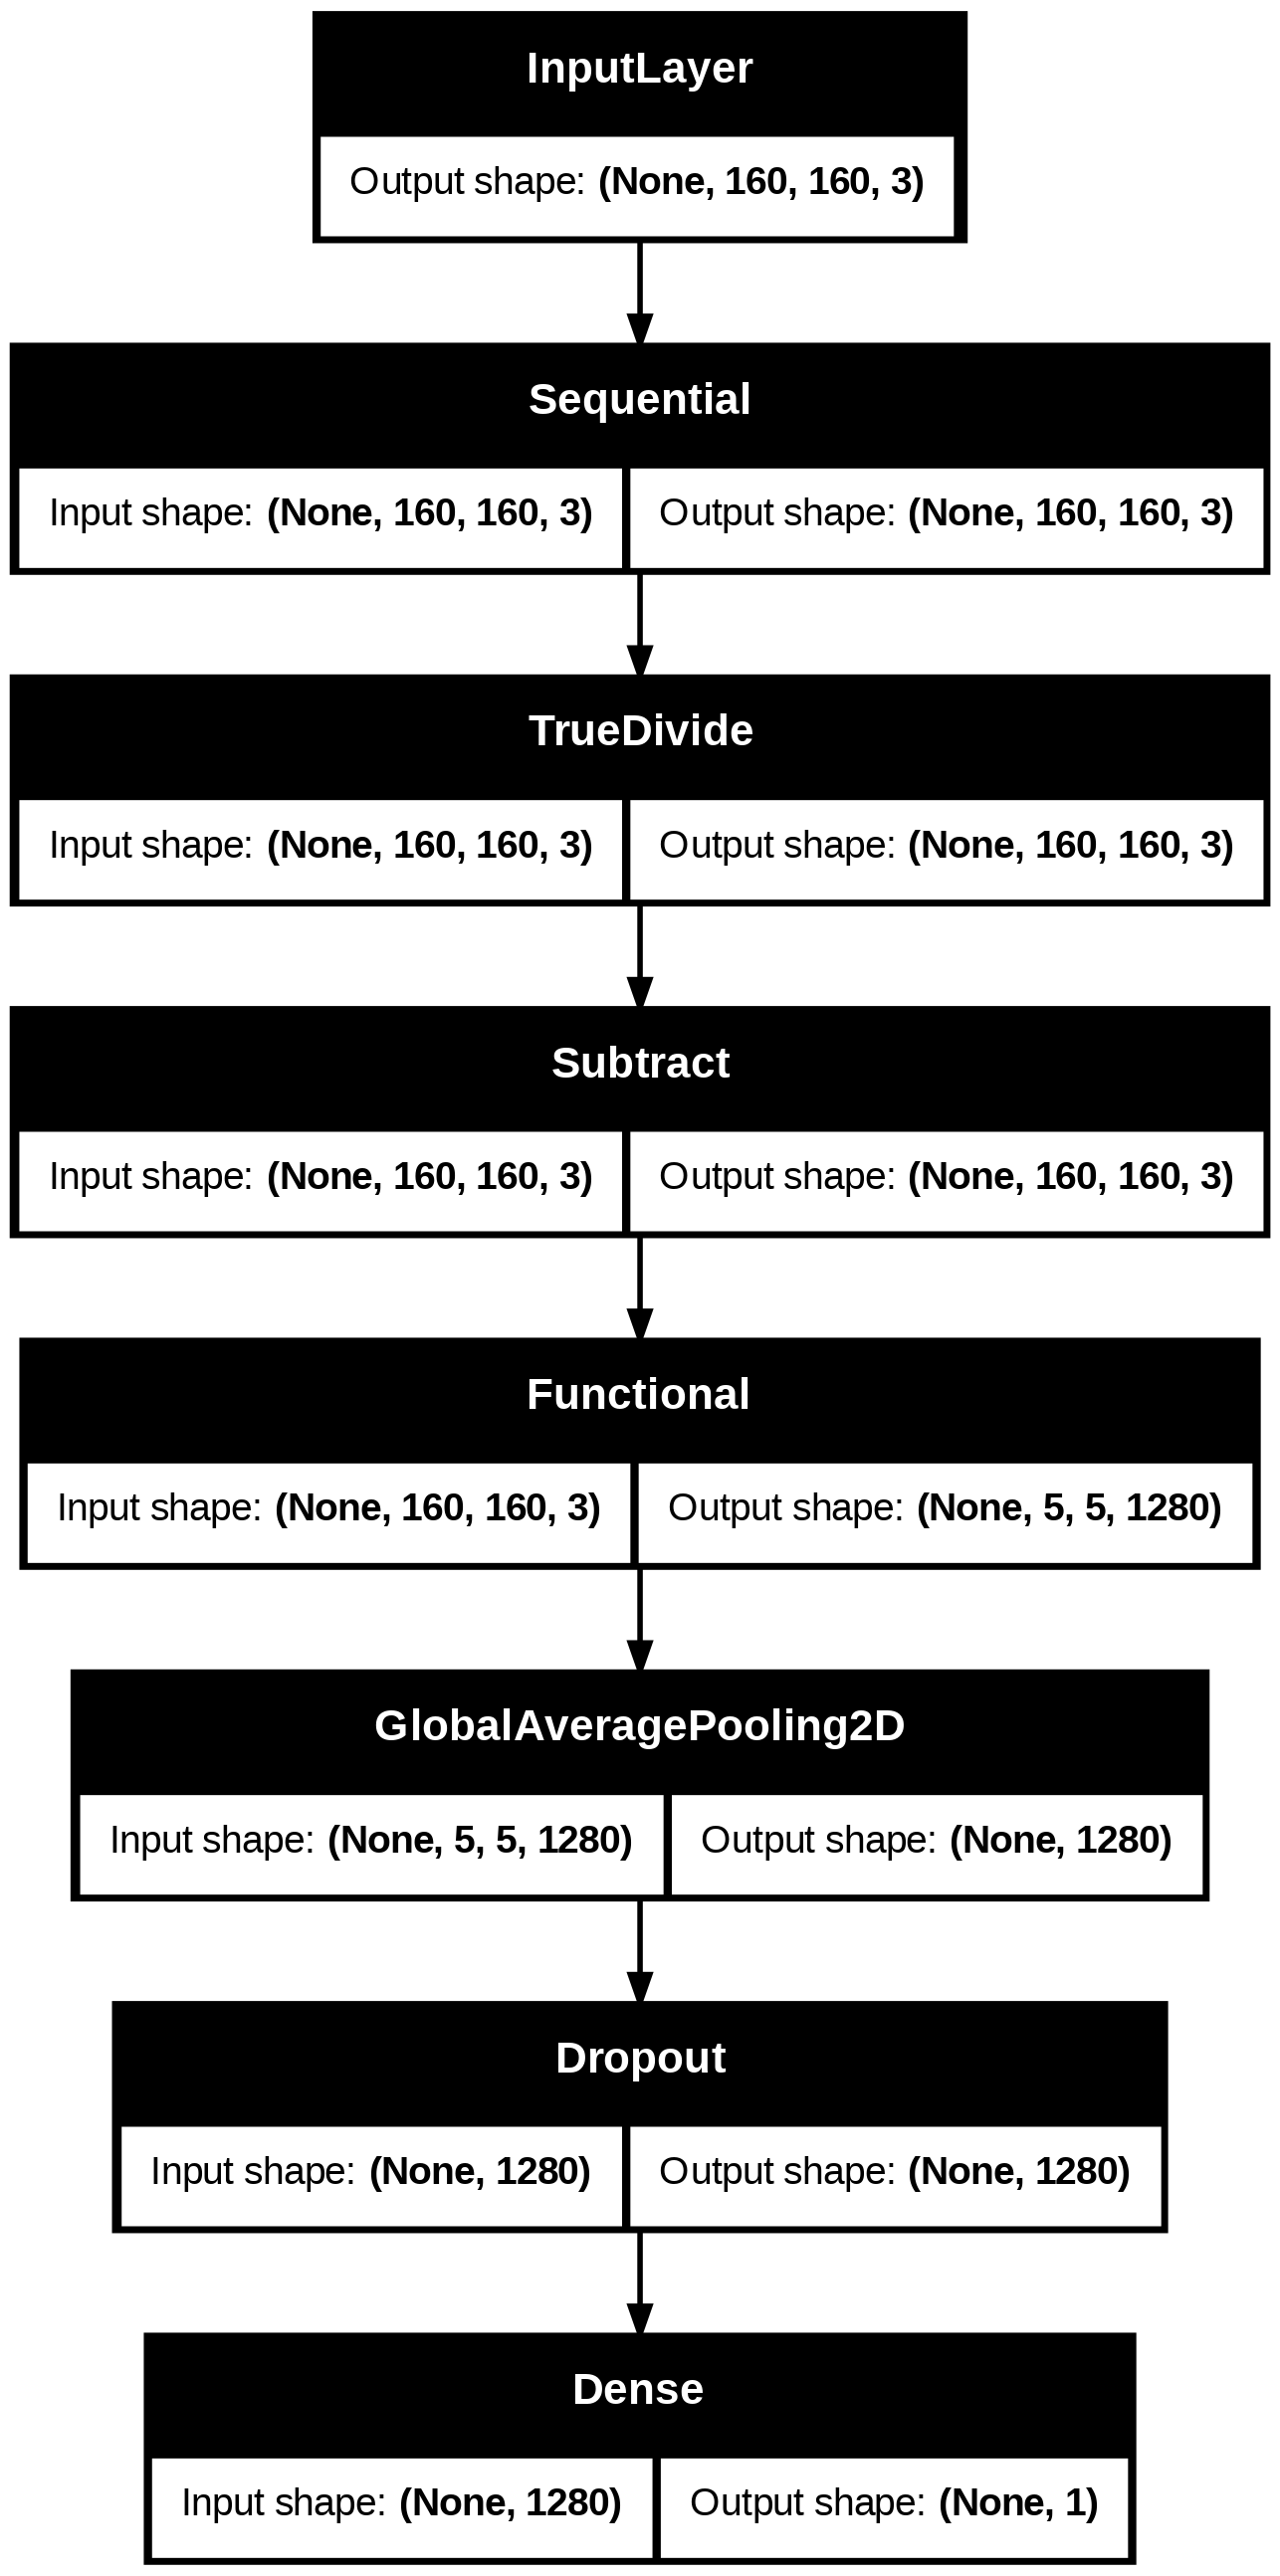

In [22]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [23]:
base_model.trainable = True

In [24]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


In [25]:
base_learning_rate = 0.0001

In [26]:
initial_epochs = 10

In [28]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate),
              metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0, name='accuracy')])

In [29]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 278ms/step - accuracy: 0.8173 - loss: 0.3256 - val_accuracy: 0.9940 - val_loss: 0.0147
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 256ms/step - accuracy: 0.9866 - loss: 0.0314 - val_accuracy: 0.9940 - val_loss: 0.0079
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.9877 - loss: 0.0301 - val_accuracy: 0.9940 - val_loss: 0.0147
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.9983 - loss: 0.0075 - val_accuracy: 0.9940 - val_loss: 0.0111
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 264ms/step - accuracy: 0.9997 - loss: 0.0039 - val_accuracy: 0.9940 - val_loss: 0.0074
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 284ms/step - accuracy: 0.9985 - loss: 0.0041 - val_accuracy: 0.9940 - val_loss: 0.0175
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 243ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9940 - val_loss: 0.0082
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 333ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1

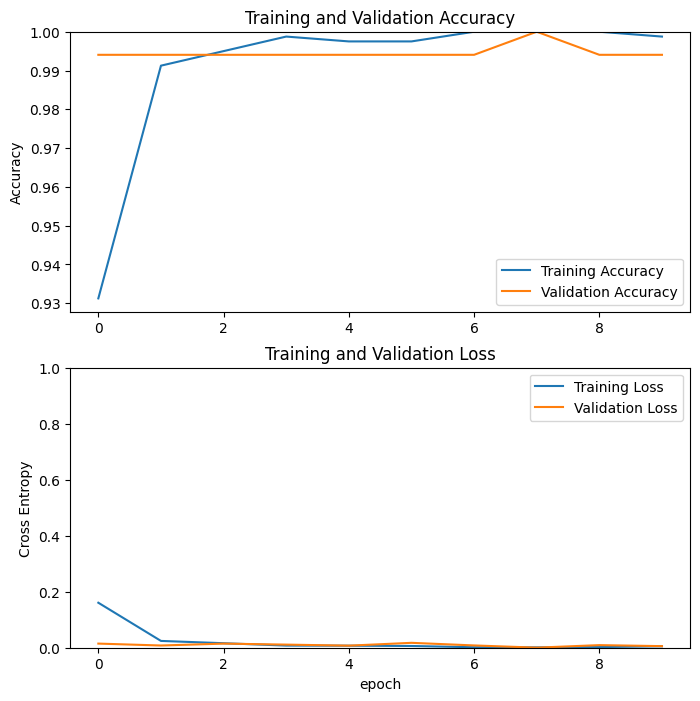

In [30]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()